# Classroom Cheating Detection Assistant
**AI Project Design and Development — Lab 01 Tasks 04 and 05**

**Student:** Hassan Bin Saqib — **Roll No.:** 231170

## Problem Statement
A teacher cannot watch every student at the same time during an exam. The proposed system uses a classroom camera to flag visible phones and repeated suspicious movement so the teacher can review them.

## Core Objectives
- Read a classroom camera feed and detect people and visible phones.
- Keep detections linked to the correct student using tracking in a later prototype.
- Flag repeated suspicious behavior instead of reacting to a single glance.
- Save an event record for teacher review.
- Keep processing and event storage local where possible.

### Environment Requirements
Python 3.12, the isolated **aipdd_env** environment, and CPU versions of PyTorch and torchvision. The installed package versions are pinned in `requirements.txt`.

```powershell
. .\aipdd_env\Scripts\Activate.ps1
python -m jupyter notebook notebooks/lab01_setup.ipynb
```

### Scope of This Lab
This notebook verifies setup and basic CPU operations. Training, real camera detection and performance targets will be evaluated in later labs. A suspicious event needs human review.


In [1]:
import sys
from pathlib import Path
import numpy as np
import cv2
import torch
import torchvision
import ultralytics
import matplotlib
import matplotlib.pyplot as plt
import IPython

print("Python:", sys.version.split()[0])
print("Kernel executable:", sys.executable)
print("Environment:", Path(sys.prefix).name)
assert Path(sys.prefix).name == "aipdd_env", "Choose the aipdd_env kernel"
for name, package in [("numpy", np), ("cv2", cv2), ("torch", torch),
                      ("torchvision", torchvision), ("ultralytics", ultralytics),
                      ("matplotlib", matplotlib), ("IPython", IPython)]:
    print(f"{name}: {package.__version__}")
print("CUDA available:", torch.cuda.is_available())
print("Kernel and library imports verified successfully.")


WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\HP\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


Python: 3.12.0
Kernel executable: D:\Air Uni Notes\Semester 7\AI Project Design & Development (AIPDD)\Lab\Lab 1-3\GitHub\aipdd_env\Scripts\python.exe
Environment: aipdd_env
numpy: 2.5.2
cv2: 5.0.0
torch: 2.14.1+cpu
torchvision: 0.29.1+cpu
ultralytics: 8.4.173
matplotlib: 3.11.2
IPython: 9.17.1
CUDA available: False
Kernel and library imports verified successfully.


## Basic CPU Verification
The following small synthetic image checks NumPy, OpenCV, Matplotlib and a PyTorch CPU tensor. This is a setup check, not a trained cheating detector.


Original image shape: (120, 180, 3)
Preprocessed image shape: (64, 64, 3)
Normalized range: 0.0 1.0
CPU tensor shape: (1, 3, 64, 64)
Tensor device: cpu


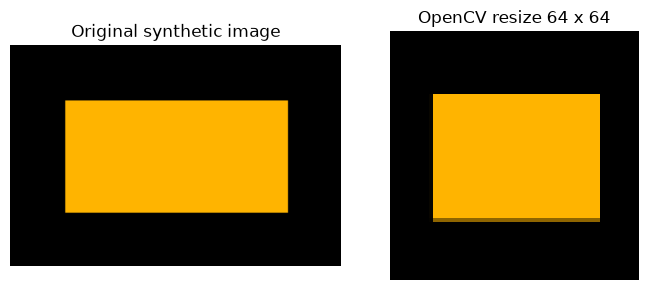

In [2]:
image = np.zeros((120, 180, 3), dtype=np.uint8)
cv2.rectangle(image, (30, 30), (150, 90), (0, 180, 255), -1)
resized = cv2.resize(image, (64, 64))
normalized = resized.astype(np.float32) / 255.0
tensor = torch.from_numpy(normalized).permute(2, 0, 1).unsqueeze(0).to("cpu")
print("Original image shape:", image.shape)
print("Preprocessed image shape:", normalized.shape)
print("Normalized range:", float(normalized.min()), float(normalized.max()))
print("CPU tensor shape:", tuple(tensor.shape))
print("Tensor device:", tensor.device)
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original synthetic image")
axes[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[1].set_title("OpenCV resize 64 x 64")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
